## Manual linear regression

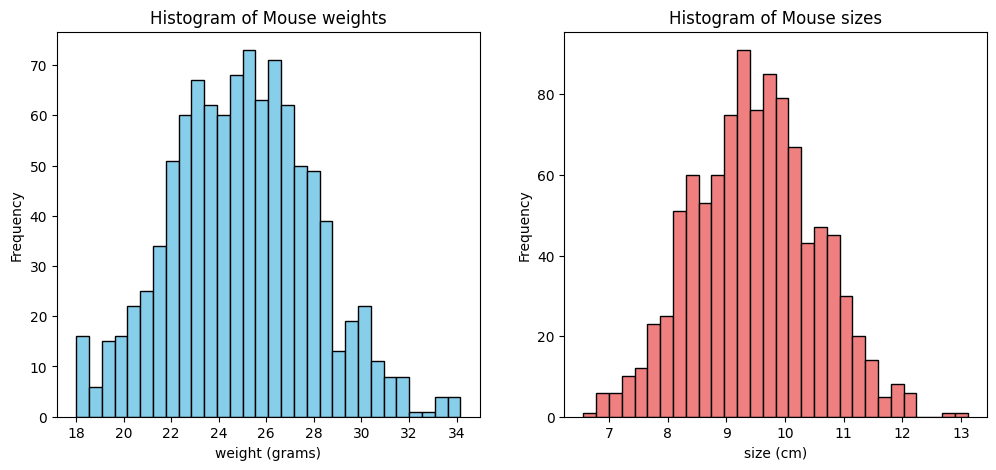

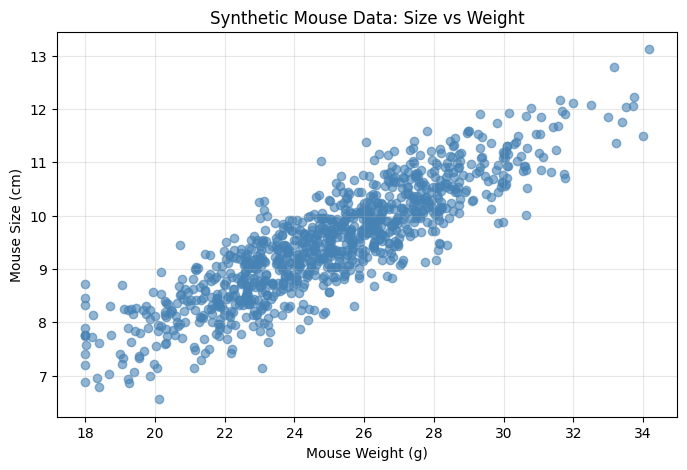

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(44)
sample_size = 1000  # number of samples

# Realistic adult mouse measurements
weight = np.random.normal(loc=25, scale=3, size=sample_size)  # 25g average
weight = np.clip(weight, 18, 35)

# True relationship: ~0.3 cm per gram (realistic proportion)
true_slope = 0.3
true_intercept = 2

noise = np.random.normal(loc=0, scale=0.5, size=sample_size)
size = true_slope * weight + true_intercept + noise

# Plot histogram of mouse weights and mouse sizes
fig, axs = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)
axs[0, 0].hist(weight, bins=30, color="skyblue", edgecolor="black")
axs[0, 0].set_xlabel("weight (grams)")
axs[0, 0].set_ylabel("Frequency")
axs[0, 0].set_title("Histogram of Mouse weights")

axs[0, 1].hist(size, bins=30, color="lightcoral", edgecolor="black")
axs[0, 1].set_xlabel("size (cm)")
axs[0, 1].set_ylabel("Frequency")
axs[0, 1].set_title("Histogram of Mouse sizes")
plt.show()

# Create DataFrame
df = pd.DataFrame({"weight_g": weight, "size_cm": size})

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df["weight_g"], df["size_cm"], alpha=0.6, c="steelblue")
plt.xlabel("Mouse Weight (g)")
plt.ylabel("Mouse Size (cm)")
plt.title("Synthetic Mouse Data: Size vs Weight")
plt.grid(True, alpha=0.3)
plt.show()

Normalized both Variables

$$x_{norm} = \frac{x - \bar{x}}{sd_x}$$

$$y_{norm} = \frac{y - \bar{y}}{sd_y}$$

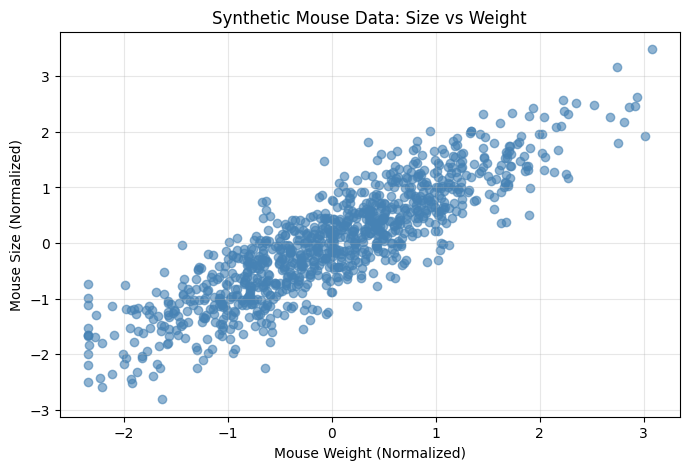

In [16]:
# scale between 0 and 1
x = df["weight_g"]
y = df["size_cm"]

x_mean = x.mean()
x_std = x.std()
x_norm = (x - x_mean) / x_std

y_mean = y.mean()
y_std = y.std()
y_norm = (y - y_mean) / y_std


# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x_norm, y_norm, alpha=0.6, c="steelblue")
plt.xlabel("Mouse Weight (Normalized)")
plt.ylabel("Mouse Size (Normalized)")
plt.title("Synthetic Mouse Data: Size vs Weight")
plt.grid(True, alpha=0.3)
plt.show()

Iteration 0: Loss=0.9990, Slope=0.0000, Intercept=0.0000
Iteration 10: Loss=0.7459, Slope=0.1596, Intercept=-0.0000
Iteration 20: Loss=0.5769, Slope=0.2901, Intercept=-0.0000
Iteration 30: Loss=0.4640, Slope=0.3967, Intercept=-0.0000
Iteration 40: Loss=0.3886, Slope=0.4838, Intercept=-0.0000
Iteration 50: Loss=0.3383, Slope=0.5550, Intercept=-0.0000
Iteration 60: Loss=0.3046, Slope=0.6132, Intercept=-0.0000
Iteration 70: Loss=0.2822, Slope=0.6607, Intercept=-0.0000
Iteration 80: Loss=0.2672, Slope=0.6996, Intercept=-0.0000
Iteration 90: Loss=0.2571, Slope=0.7313, Intercept=-0.0000
Iteration 100: Loss=0.2505, Slope=0.7573, Intercept=-0.0000
Iteration 110: Loss=0.2460, Slope=0.7785, Intercept=-0.0000
Iteration 120: Loss=0.2430, Slope=0.7959, Intercept=-0.0000
Iteration 130: Loss=0.2410, Slope=0.8100, Intercept=-0.0000
Iteration 140: Loss=0.2397, Slope=0.8216, Intercept=-0.0000
Iteration 150: Loss=0.2388, Slope=0.8311, Intercept=-0.0000
Iteration 160: Loss=0.2382, Slope=0.8388, Intercept=

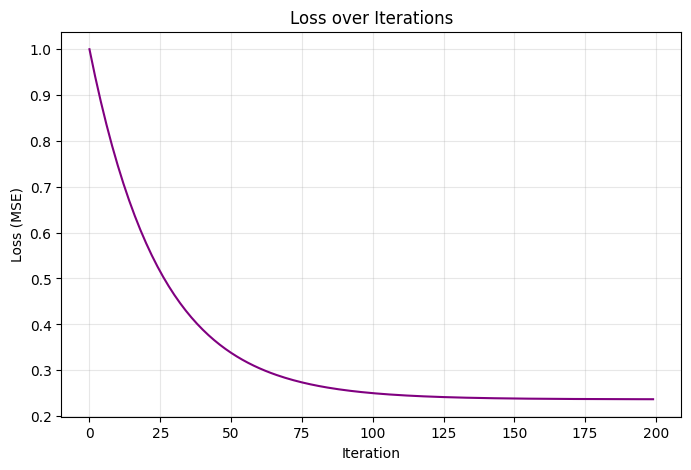

In [17]:
def compute_gradient(n, x: pd.Series, y: pd.Series, y_pred: pd.Series):
    # calculate partial derivatives for b and m using the MSE loss function
    error = y - y_pred
    b_par = -2 / n * error.sum()
    m_par = -2 / n * (error * x).sum()

    return b_par, m_par


m = 0.0  # initial slope
b = 0.0  # initial intercept
learning_rate = 0.01

iterations = 200

losses = []
i = 0
while True:
    y_pred = m * x_norm + b
    # for linear regression, we can use mean squared error method as the loss function
    loss = np.mean((y_norm - y_pred) ** 2)
    losses.append(loss)
    b_par, m_par = compute_gradient(len(df), x_norm, y_norm, y_pred)
    if i % 10 == 0:
        print(f"Iteration {i}: Loss={loss:.4f}, Slope={m:.4f}, Intercept={b:.4f}")

    i += 1
    if i >= iterations:
        print(f"Iteration {i}: Loss={loss:.4f}, Slope={m:.4f}, Intercept={b:.4f}")
        break

    # update parameters
    m -= learning_rate * m_par
    b -= learning_rate * b_par

# plot the losses over iterations
plt.figure(figsize=(8, 5))
plt.plot(losses, color="purple")
plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title("Loss over Iterations")
plt.grid(True, alpha=0.3)
plt.show()

Final slope (m):     0.8576
Final intercept (b): -0.0000
Equation: size = 0.8576 × weight + (-0.0000)


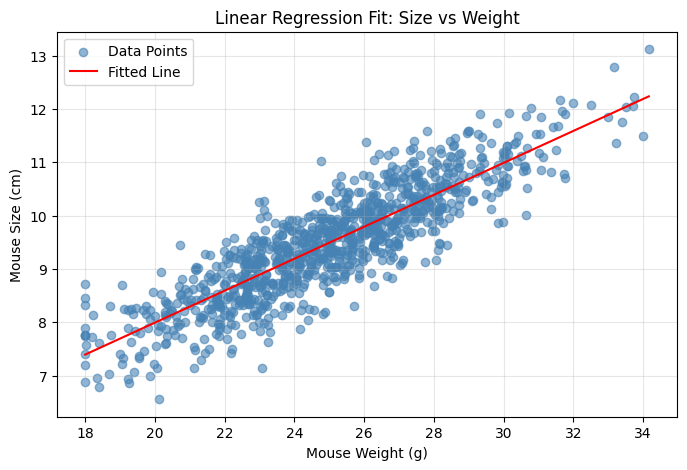

Manual Linear Regression Coefficients:
  Slope (m):     0.8576
  Intercept (b): -0.0000
Equation: size = 0.8576 × weight + (-0.0000)
Expected MSE (normalized): 0.2307
Actual MSE (normalized):   0.2571


In [18]:
# After training converges:
print(f"Final slope (m):     {m:.4f}")
print(f"Final intercept (b): {b:.4f}")
print(f"Equation: size = {m:.4f} × weight + ({b:.4f})")

# Draw the best fitted line on data
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, c="steelblue", label="Data Points")

x_line_original = np.linspace(x.min(), x.max(), 100)
x_line_norm = (x_line_original - x_mean) / x_std
y_line_norm = m * x_line_norm + b
y_line_original = y_line_norm * y_std + y_mean  # back to cm

plt.plot(x_line_original, y_line_original, color="red", label="Fitted Line")
plt.xlabel("Mouse Weight (g)")
plt.ylabel("Mouse Size (cm)")
plt.title("Linear Regression Fit: Size vs Weight")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

y_pred_norm = m * x_norm + b
y_pred_original = y_pred_norm * y_std + y_mean

print(f"Manual Linear Regression Coefficients:")
print(f"  Slope (m):     {m:.4f}")
print(f"  Intercept (b): {b:.4f}")
print(f"Equation: size = {m:.4f} × weight + ({b:.4f})")
mse_original = np.mean((y - y_pred_original) ** 2)

# Sanity check: what should MSE be in normalized space?
noise_variance = 0.5**2  # you set scale=0.5
expected_mse_norm = noise_variance / y_std**2
print(f"Expected MSE (normalized): {expected_mse_norm:.4f}")
print(f"Actual MSE (normalized):   {mse_original:.4f}")

In [19]:
m_original = m * (y_std / x_std)
b_original = y_mean - m_original * x_mean

print(f"Recovered slope:     {m_original:.4f}  (true slope: {true_slope})")
print(f"Recovered intercept: {b_original:.4f}  (true intercept: {true_intercept})")

Recovered slope:     0.2993  (true slope: 0.3)
Recovered intercept: 2.0089  (true intercept: 2)


## Comparison with SK Learn

In [20]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(x.values.reshape(-1, 1), y)
print(f"Sklearn Linear Regression Coefficients:")
print(f"  Slope (m):     {reg.coef_[0]:.4f}")
print(f"  Intercept (b): {reg.intercept_:.4f}")
print(f"Equation: size = {reg.coef_[0]:.4f} × weight + ({reg.intercept_:.4f})")
print("MSE:", np.mean((y - reg.predict(x.values.reshape(-1, 1))) ** 2))

Sklearn Linear Regression Coefficients:
  Slope (m):     0.3048
  Intercept (b): 1.8716
Equation: size = 0.3048 × weight + (1.8716)
MSE: 0.25684643800665663


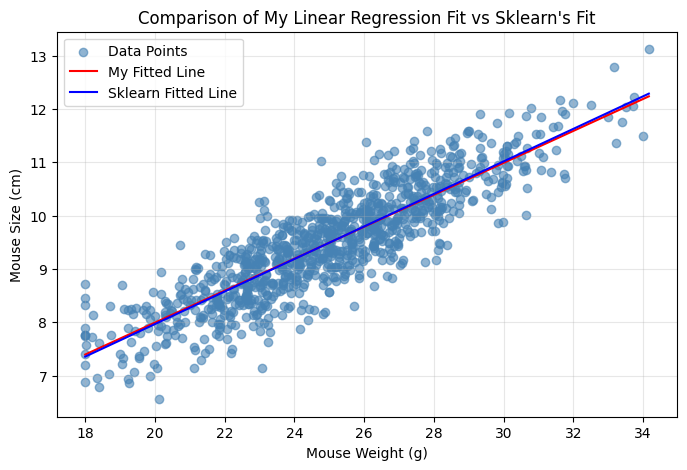

In [21]:
# Draw the my best fitted line and sklearn best fitted line on data
plt.figure(figsize=(8, 5))
plt.scatter(
    df["weight_g"], df["size_cm"], alpha=0.6, c="steelblue", label="Data Points"
)
x_line = np.linspace(df["weight_g"].min(), df["weight_g"].max(), 100)
my_fitted_line = m_original * x_line + b_original
sklearn_fitted_line = reg.coef_[0] * x_line + reg.intercept_
plt.plot(x_line, my_fitted_line, color="red", label="My Fitted Line")
plt.plot(x_line, sklearn_fitted_line, color="blue", label="Sklearn Fitted Line")
plt.xlabel("Mouse Weight (g)")
plt.ylabel("Mouse Size (cm)")
plt.title("Comparison of My Linear Regression Fit vs Sklearn's Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusion

Here we implemented Manual linear regression which results similar to scikit‑learn using the normal equation with an intercept.